In [96]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
import sys
import numpy as np
from numpy import pi as pi
import os
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import glob
import pandas as pd
import time
import scipy as sp
from pprint import pprint
import matplotlib.gridspec as gridspec

import pickle
import math as m
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib
import random

import icewave.display.graphes as graphes
import icewave.tools.rw_data as rw

In [98]:
savefolder = '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Velocity_Fields/'

In [103]:
filelist = glob.glob('/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/*_U_0*forced*/res-*.txt')

#pprint(filelist)
times = [int(filename.split('res-')[1].split('.txt')[0]) for filename in filelist]
#print(times)
indices = np.argsort(times)
#print(indices)
filelist = np.asarray(filelist)[indices]

pprint(filelist)

nx = 256
ny = 256

d = {}
keys = ['ux','uy','p','f','s']

for i,filename in enumerate(filelist):
#filename = filelist[0]
    print(i)
    data = np.asarray(rw.read_csv(filename,delimiter=' '))[:,:-1].astype(float)
    ns,nd = data.shape
    data = np.reshape(data,(nx,ny,7))
    
    for j,key in enumerate(keys):
        if i==0:
            d['x']=data[...,0]
            d['y']=data[...,1]
            d[key]=[data[...,j+2]]
        else:
            d[key].append(data[...,j+2])

for key in d.keys():
    d[key] = np.asarray(d[key])
print(d[key].shape)

['/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1736.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1722.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1723.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1737.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1709.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1721.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1735.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1734.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_Surface/Data/256_U_0_4_forced_w0_n0p4_A_50mm/res-1720.txt',
 '/Users/stephane/Documents/git/Notebooks/Jet_

In [104]:
nt,nx,ny = d['ux'].shape

(101, 95)


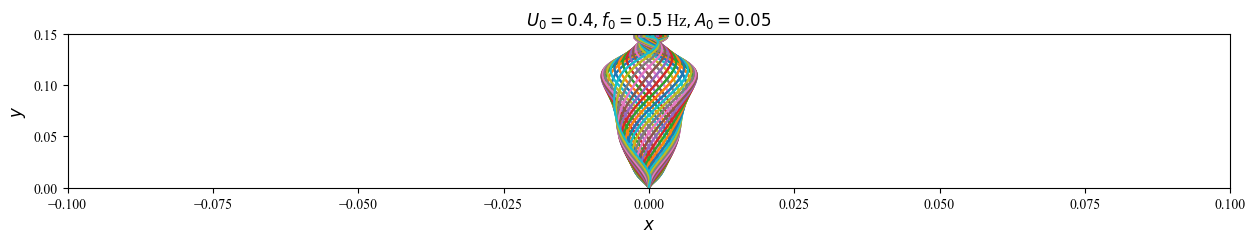

In [113]:
x,y,ux,uy,p = d['x'],d['y'],d['ux'],d['uy'],d['p']
f = d['f']

fig,ax = plt.subplots(figsize=(15,2))#,ncols=3)

Mx = {}
My = {}
Mf = {}
jmax = 95
U0 = 0.4
A0 = 0.05
for j in range(nt):
    for n in range(3):
        x = d['x'][64:128+64,:jmax]
        y = d['y']

        ux = d['ux'][j,64:128+64,:jmax]
        uy = d['uy'][j,64:128+64,:jmax]
        f = d['f'][j,...]

        if j==0:        
            Mx[n]= [np.sum(x**n*ux,axis=0)]
            My[n]= [np.sum(x**n*uy,axis=0)]
            Mf[n] = [np.sum(y**n*f,axis=1)]
        else:
            Mx[n].append(np.sum(x**n*ux,axis=0))
            My[n].append(np.sum(x**n*uy,axis=0))
            Mf[n].append(np.sum(y**n*f,axis=1))

    
for key in Mx.keys():
    Mx[key] = np.asarray(Mx[key])
    My[key] = np.asarray(My[key])
    Mf[key] = np.asarray(Mf[key])

print(Mx[0].shape)
#My[n]= np.sum(d['x']**n*d['u'+c],axis=0)

t = 50
y = d['y'][127,:jmax]
for t in range(0,100):
    plt.plot(My[1][t,:]/My[0][t,:],y)

plt.axis([-0.1,0.1,0,0.15])
name = f'$U_0 = {U0}, f_0 = 0.5$ Hz$, A_0 = {A0}$'
figs = graphes.legende('$x$','$y$',name)
graphes.save_figs(figs,savedir=savefolder,prefix='Jet_',overwrite=True)

(101, 256, 256)

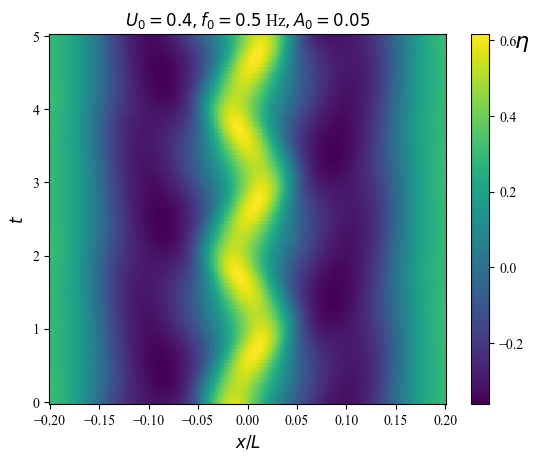

In [122]:
eta = Mf[0]-np.mean(Mf[0],axis=(0,1))
L = 0.4
dt = 0.05
x = np.linspace(-L/2,L/2,nx)
t = np.arange(nt)*dt
plt.pcolormesh(x,t,eta)
cbar  = plt.colorbar()
cbar.set_label(r'$\eta$', rotation=0,loc='top',fontsize=16)
figs = graphes.legende('$x/L$','$t$',name)
graphes.save_figs(figs,savedir=savefolder,prefix = 'Surface_',frmt='png')

In [60]:
g = 9.81
h = 0.15
print(np.sqrt(g/h)*2*np.pi)

50.8122870113615


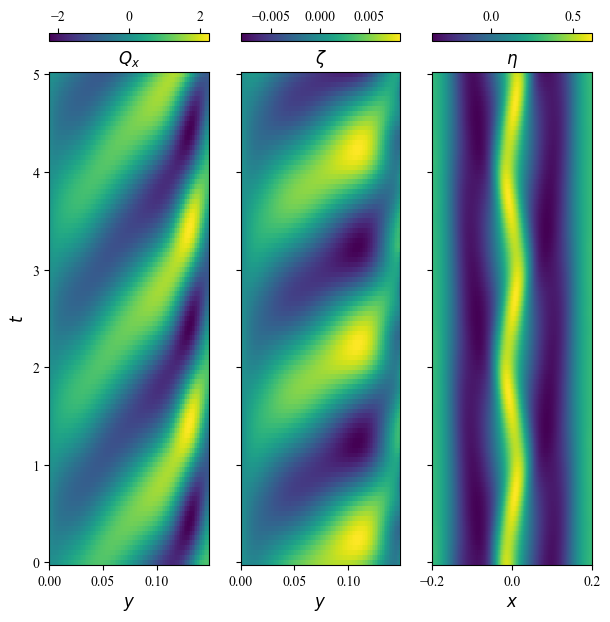

In [95]:
y = d['y'][127,:jmax]
x = d['x'][:,127]

dt = 0.05
t = np.arange(nt)*dt
Zeta = My[1]/My[0]
eta = Mf[0]-np.mean(Mf[0],axis=(0,1))

fig,axs = plt.subplots(figsize=(7,8),ncols=3,sharey=True)


ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]

sc = ax1.pcolormesh(y,t,Mx[0])
plt.colorbar(sc,location='top')
graphes.legende('$y$','$t$','$Q_x$',ax=ax1)

sc = ax2.pcolormesh(y,t,Zeta)
plt.colorbar(sc,location='top')
figs = graphes.legende('$y$','',r'$\zeta$',ax=ax2)

sc = ax3.pcolormesh(x,t,eta)
plt.colorbar(sc,location='top')
figs = graphes.legende('$x$','',r'$\eta$',ax=ax3)

#fig.subplots_adjust(wspace=0)
#axs[2].pcolormesh(x,t,Zeta)

#plt.axis([-0.1,0.1,0,0.15])

graphes.save_figs(figs,savedir=savefolder,overwrite=True)

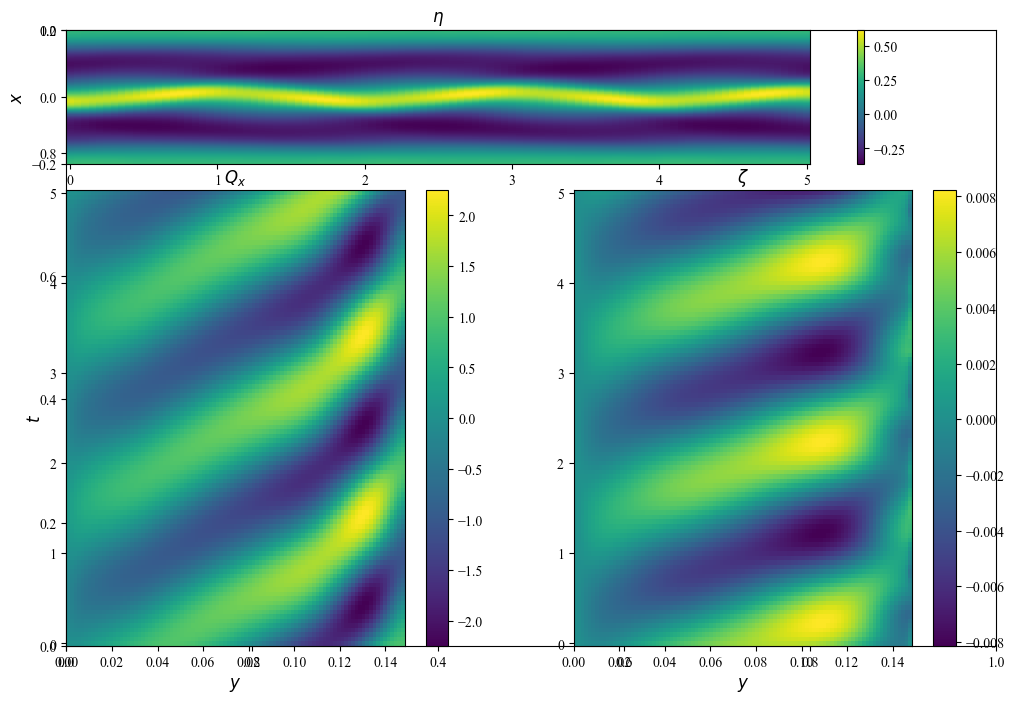

In [89]:
x = d['x'][:,127]
y = d['y'][127,:jmax]
dt = 0.05
t = np.arange(nt)*dt
Zeta = My[1]/My[0]

fig,axs = plt.subplots(figsize=(12,8))#,ncols=2,sharey=True)
gs = gridspec.GridSpec(4, 2)

ax3 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])

sc = ax1.pcolormesh(y,t,Mx[0])
plt.colorbar(sc)
graphes.legende('$y$','$t$','$Q_x$',ax=ax1)

sc = ax2.pcolormesh(y,t,Zeta)
plt.colorbar(sc)
figs = graphes.legende('$y$','',r'$\zeta$',ax=ax2)

sc = ax3.pcolormesh(t,x,np.transpose(eta))
plt.colorbar(sc)
figs = graphes.legende('$t$','$x$',r'$\eta$',ax=ax3)

#fig.subplots_adjust(wspace=0)
#axs[2].pcolormesh(x,t,Zeta)

#plt.axis([-0.1,0.1,0,0.15])



In [ ]:
y = d['y'][127,:jmax]
t = np.arange(nt)
Zeta = My[1]/My[0]

fig,ax = plt.subplots(figsize=(3,10))#,ncols=3)

ax.pcolormesh(y,t,Mx[0])
#plt.axis([-0.1,0.1,0,0.15])

95.99999999999999


(np.float64(-0.05), np.float64(0.05), np.float64(-0.1), np.float64(0.45))

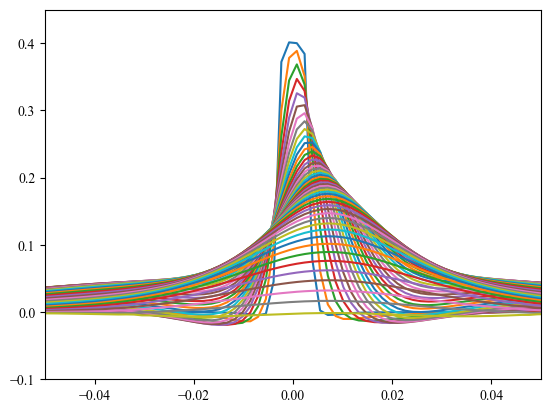

In [64]:
d['ux'].shape

print(0.15/0.4*256)


for i in range(0,97,2):
    plt.plot(d['x'][:,i],d['uy'][:,i])

plt.axis([-0.05,0.05,-0.1,0.45])

In [59]:
d['x'][64:128+64,0]

array([-0.0992188 , -0.0976562 , -0.0960938 , -0.0945313 , -0.0929688 ,
       -0.0914063 , -0.0898438 , -0.0882813 , -0.0867188 , -0.0851563 ,
       -0.0835938 , -0.0820312 , -0.0804688 , -0.0789063 , -0.0773438 ,
       -0.0757813 , -0.0742188 , -0.0726563 , -0.0710938 , -0.0695313 ,
       -0.0679687 , -0.0664062 , -0.0648438 , -0.0632813 , -0.0617188 ,
       -0.0601562 , -0.0585938 , -0.0570313 , -0.0554688 , -0.0539063 ,
       -0.0523437 , -0.0507812 , -0.0492188 , -0.0476563 , -0.0460937 ,
       -0.0445312 , -0.0429688 , -0.0414063 , -0.0398438 , -0.0382812 ,
       -0.0367187 , -0.0351562 , -0.0335938 , -0.0320313 , -0.0304687 ,
       -0.0289062 , -0.0273438 , -0.0257813 , -0.0242188 , -0.0226562 ,
       -0.0210937 , -0.0195312 , -0.0179688 , -0.0164063 , -0.0148437 ,
       -0.0132812 , -0.0117188 , -0.0101563 , -0.00859375, -0.00703125,
       -0.00546875, -0.00390625, -0.00234375, -0.00078125,  0.00078125,
        0.00234375,  0.00390625,  0.00546875,  0.00703125,  0.00

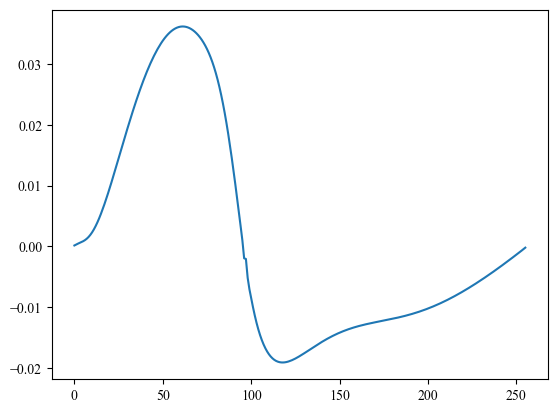

In [79]:
x,y,ux,uy,p = d['x'],d['y'],d['ux'],d['uy'],d['p']

n = 1
c = 'y'

Mx = {}
My = {}
for n in range(3):
    Mx[n]= np.sum(d['x'][64:128+64,:]**n*d['ux'][64:128+64,:],axis=0)
    My[n]= np.sum(d['x'][64:128+64,:]**n*d['uy'][64:128+64,:],axis=0)
    #My[n]= np.sum(d['x']**n*d['u'+c],axis=0)

plt.plot(My[1])

95.99999999999999
-0.0026512693066500226


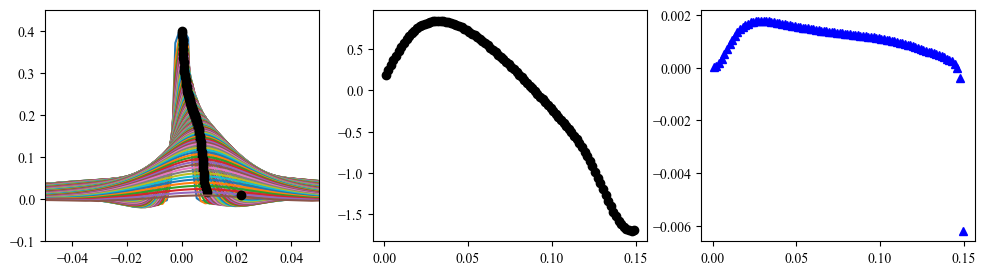

In [90]:
d['ux'].shape

print(0.15/0.4*256)
fig,axs = plt.subplots(figsize=(12,3),ncols=3)

dx = np.diff(d['x'][:,i])[0]

for i in range(0,96):
    axs[0].plot(d['x'][:,i],d['uy'][:,i])
    Umax = np.max(d['uy'][:,i])
    axs[0].plot(My[1][i]/My[0][i],Umax,'ko')
    axs[1].plot(d['y'][127,i],Mx[0][i],'ko')

    #axs[2].plot(d['y'][127,i],Mx[2][i]/Mx[0][i],'k>')
    axs[2].plot(d['y'][127,i],My[2][i]/My[0][i],'b^')

axs[0].axis([-0.05,0.05,-0.1,0.45])


print(np.sum(Mx[0][i])*dx)

95.99999999999999


(np.float64(-0.2), np.float64(0.2), np.float64(0.0), np.float64(1.1))

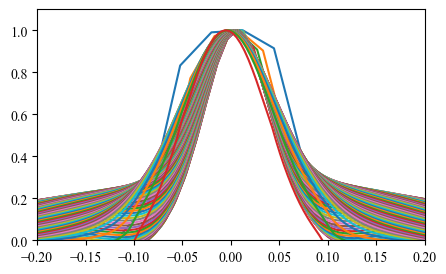

In [102]:
d['ux'].shape

print(0.15/0.4*256)
fig,ax = plt.subplots(figsize=(5,3))#,ncols=3)

dx = np.diff(d['x'][:,i])[0]

for i in range(1,95):
    Umax = np.max(d['uy'][:,i])
    X = My[1][i]/My[0][i]

    ax.plot((d['x'][:,i]-X)/d['y'][127,i]**(1/2),d['uy'][:,i]/Umax)

ax.axis([-0.2,0.2,0,1.1])
#    axs[0].plot(,Umax,'ko')
#    axs[1].plot(d['y'][127,i],Mx[0][i],'ko')


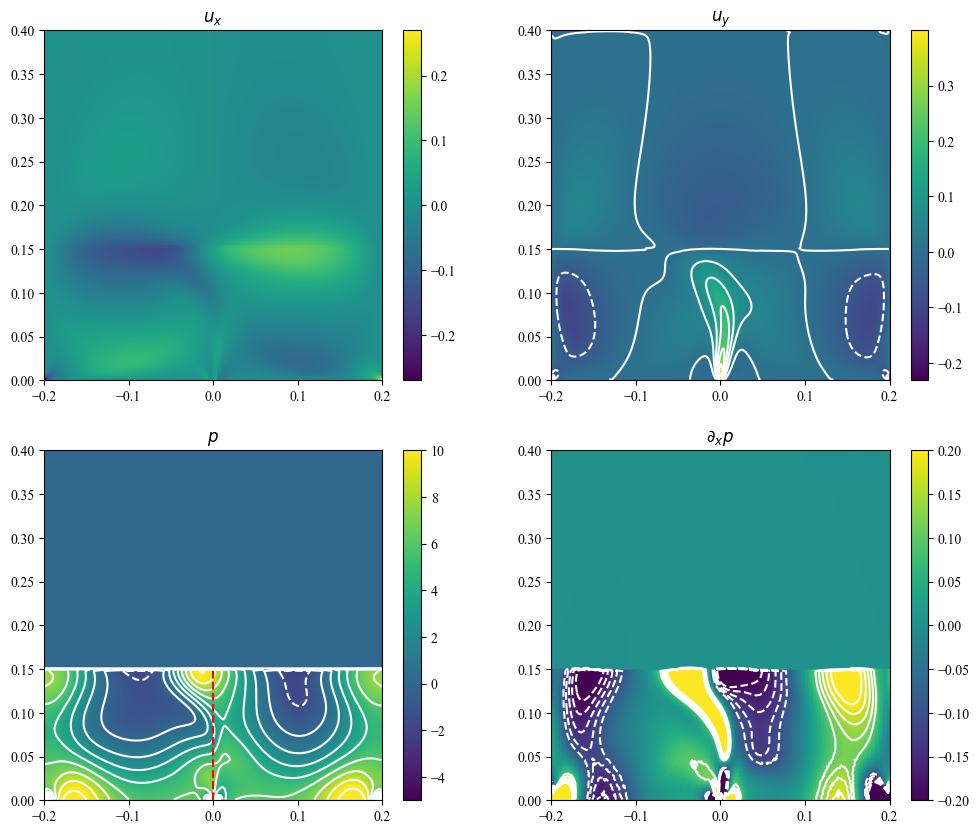

In [127]:
fig,axs = plt.subplots(figsize=(12,10),ncols=2,nrows=2)

i = 0
x,y,ux,uy,p = d['x'],d['y'],d['ux'][i,...],d['uy'][i,...],d['p'][i,...]

sc = axs[0,0].pcolormesh(x,y,ux)
plt.colorbar(sc)
graphes.legende('','',r'$u_x$',ax = axs[0,0])
sc = axs[0,1].pcolormesh(x,y,uy)
graphes.legende('','',r'$u_y$', ax = axs[0,1])
axs[0,1].contour(x,y,uy,10,alpha=1,colors='w')
plt.colorbar(sc)
#[X,Y] = np.meshgrid(x,y)

rho = 1000
g = 9.81
dpx = np.gradient(p)[0]
sc = axs[1,1].pcolormesh(x,y,dpx,vmin=-0.2,vmax=0.2)

contours = np.linspace(-0.2,-0.1,5)
axs[1,1].contour(x,y,dpx,contours,alpha=1,colors='w')
contours = np.linspace(0.1,0.2,5)
axs[1,1].contour(x,y,dpx,contours,alpha=1,colors='w')

graphes.legende('','',r'$\partial_x p$',ax = axs[1,1])

plt.colorbar(sc)

p0 = -9759.18447655
ys = y-0.15
pd = (p-p0*ys)*(ys<0)
sc = axs[1,0].pcolormesh(x,y,pd,vmin=-5,vmax=10)
axs[1,0].contour(x,y,pd,100,alpha=1,colors='w')

axs[1,0].plot([0,0],[0,0.15],'r--')

figs = graphes.legende('','',r'$p$',cplot=True,ax = axs[1,0])


graphes.save_figs(figs,savedir=savefolder,prefix='Field_Simu_',overwrite=True,frmt='png')
#sc = axs[1,0].pcolormesh(x,y,np.gradient(p)[0],vmin=-0.2,vmax=0.2)
#axs[1,0].axis([-0.2,0.2,0.14,0.16])
plt.colorbar(sc)



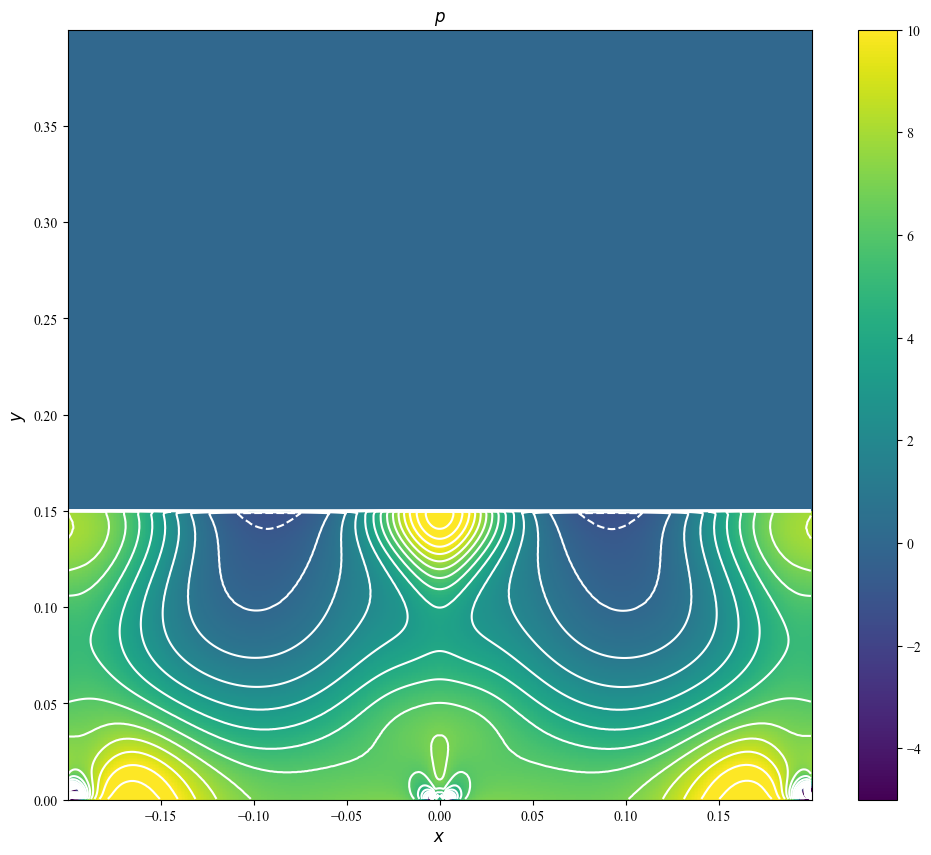

In [69]:
fig,ax = plt.subplots(figsize=(12,10))#,ncols=2,nrows=2)

p0 = -9759.18447655
ys = y-0.15
pd = (p-p0*ys)*(ys<0)
sc = ax.pcolormesh(x,y,pd,vmin=-5,vmax=10)
ax.contour(x,y,pd,200,alpha=1,colors='w')

figs = graphes.legende('$x$','$y$',r'$p$',cplot=True,ax = ax)


graphes.save_figs(figs,savedir=savefolder,prefix='Field_Pressure_',frmt='png')
#sc = axs[1,0].pcolormesh(x,y,np.gradient(p)[0],vmin=-0.2,vmax=0.2)
#axs[1,0].axis([-0.2,0.2,0.14,0.16])
plt.colorbar(sc)

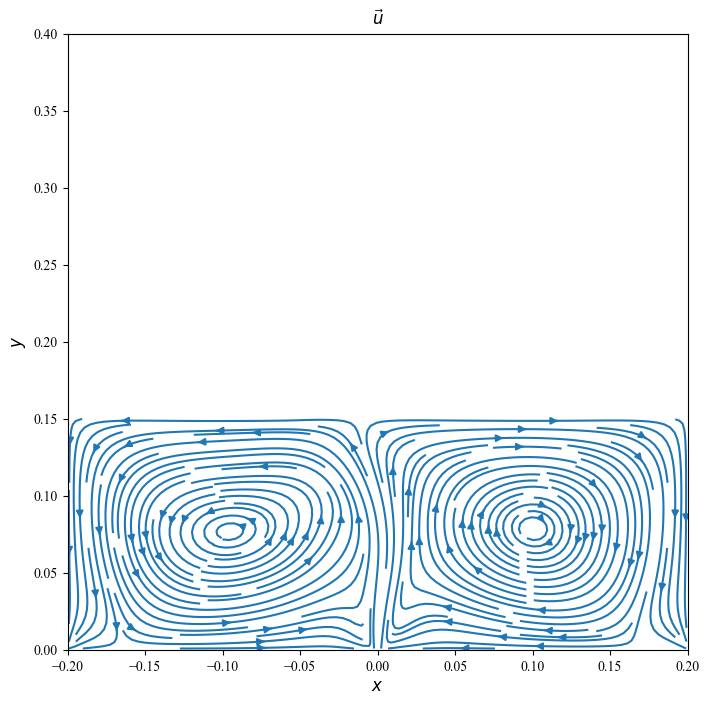

In [134]:
fig,ax = plt.subplots(figsize=(8,8))#,ncols=2,nrows=2)

p0 = -9759.18447655
ys = y-0.15
pd = (p-p0*ys)*(ys<0)
x1 = np.linspace(min(x[:,0]),max(x[:,0]),len(x[:,0]))
y1 = np.linspace(min(y[0,:]),max(y[0,:]),len(y[0,:]))

sc = ax.streamplot(x1,y1,np.transpose(ux*(ys<0)),np.transpose(uy*(ys<0)),density=3)#,vmin=-5,vmax=10)
#ax.contour(x,y,pd,200,alpha=1,colors='w')

plt.axis([-0.2,0.2,0,0.4])
figs = graphes.legende('$x$','$y$',r'$\vec u$',cplot=True,ax = ax)


graphes.save_figs(figs,savedir=savefolder,prefix='Field_Velocity_',frmt='png')
#sc = axs[1,0].pcolormesh(x,y,np.gradient(p)[0],vmin=-0.2,vmax=0.2)
#axs[1,0].axis([-0.2,0.2,0.14,0.16])
#plt.colorbar(sc)

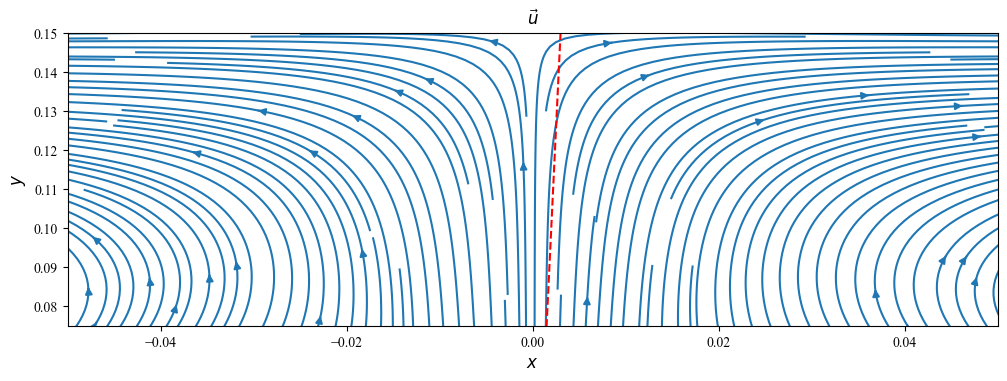

In [94]:
fig,ax = plt.subplots(figsize=(12,10*0.38))#,ncols=2,nrows=2)

p0 = -9759.18447655
ys = y-0.15
pd = (p-p0*ys)*(ys<0)
x1 = np.linspace(min(x[:,0]),max(x[:,0]),len(x[:,0]))
y1 = np.linspace(min(y[0,:]),max(y[0,:]),len(y[0,:]))

sc = ax.streamplot(x1,y1,np.transpose(ux),np.transpose(uy),density=10)#,vmin=-5,vmax=10)
#ax.contour(x,y,pd,200,alpha=1,colors='w')

yth = np.linspace(0,0.15,100)
theta = 0.02
zeta = yth*theta
ax.plot(zeta,yth,'r--')

plt.axis([-0.05,0.05,0.075,0.15])
figs = graphes.legende('$x$','$y$',r'$\vec u$',cplot=True,ax = ax)


graphes.save_figs(figs,savedir=savefolder,prefix='Field_Velocity_',frmt='png')
#sc = axs[1,0].pcolormesh(x,y,np.gradient(p)[0],vmin=-0.2,vmax=0.2)
#axs[1,0].axis([-0.2,0.2,0.14,0.16])
#plt.colorbar(sc)

191


(np.float64(-0.1), np.float64(0.1), np.float64(0.0), np.float64(20.0))

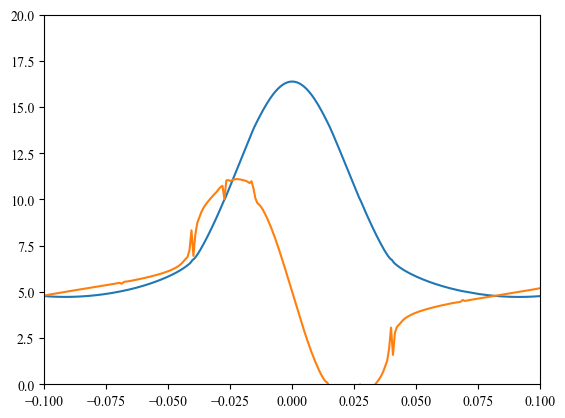

In [106]:
isurf = np.argmin(np.abs(y[0,:]-0.15))
print(isurf)

plt.plot(x[:,isurf],p[:,isurf])
plt.axis([-0.10,0.10,0,20])
dx = np.mean(np.diff(x[:,isurf]))

xc = (x[1:,isurf]+x[:-1,isurf])/2
plt.plot(xc,np.diff(p[:,isurf])*dx*3*10**4+5)
plt.axis([-0.10,0.10,0,20])

[-9759.18447655  1469.55985603]


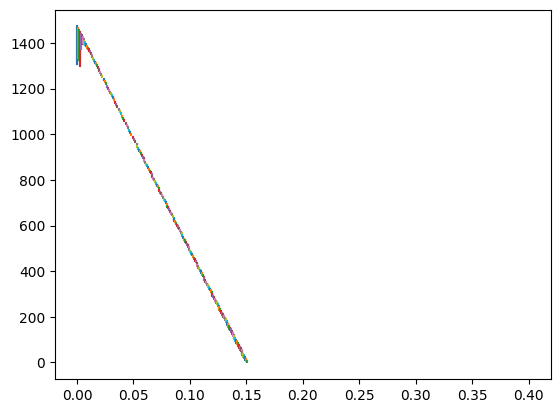

In [22]:
plt.plot(y[0,50:150],p[0,50:150])

pfit = np.polyfit(y[0,50:150],p[0,50:150],1)
print(pfit)

(np.float64(0.0), np.float64(0.15), np.float64(0.0), np.float64(0.45))

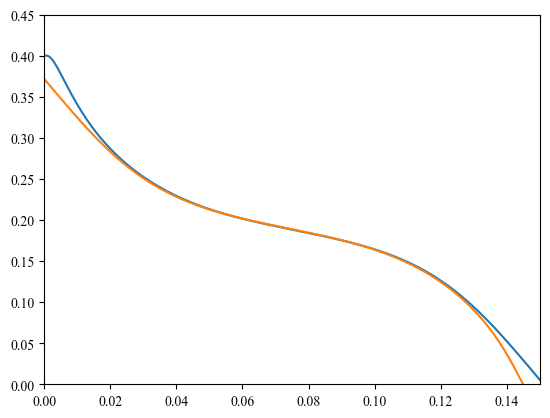

In [44]:
ic = 255
y0 = 0.15
u0 = 0.4
eps = 0.023
plt.plot(y[ic,:],uy[ic,:])
plt.plot(y0-y[ic,:],u0-uy[ic,:]-eps)

plt.axis([0,0.15,0,0.45])

(np.float64(0.0), np.float64(0.15), np.float64(0.0), np.float64(13.0))

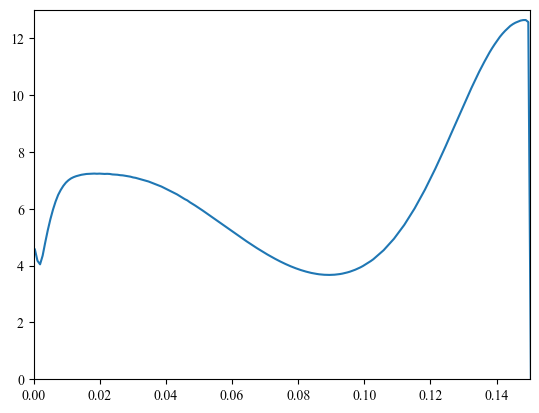

In [47]:
ic = 255
y0 = 0.15
u0 = 0.4
eps = 0.023
plt.plot(y[ic,:],pd[ic,:])
#plt.plot(y0-y[ic,:],u0-uy[ic,:]-eps)

plt.axis([0,0.15,0,13])

In [16]:
data = {}
for i,key in enumerate(damping[0,0:-1:2]):
    data[key]={}
    data[key]['t'] = damping[2:,i*2].astype(float)
    data[key]['A'] = damping[2:,i*2+1].astype(float)

In [27]:
import scipy.signal as sig


40 0.1733303159405001
40 0.16632831141182652
40 0.15091990003532918
50 0.14252351025737311
50 0.14189267616920545
50 0.1413412490083427


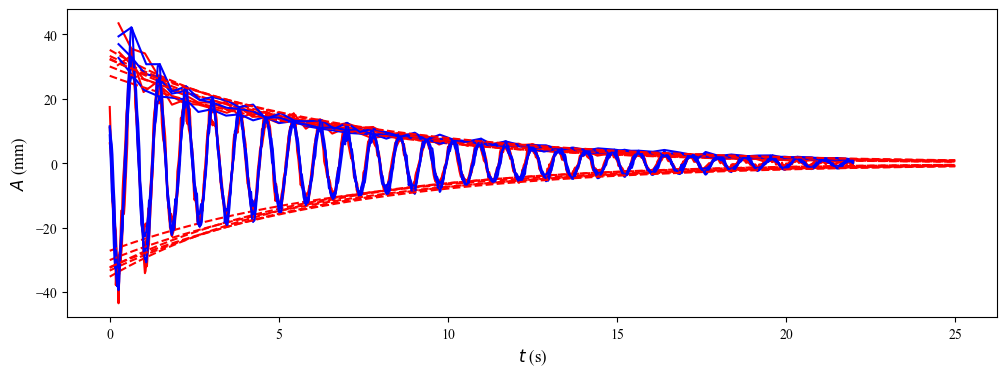

In [64]:
fig,ax = plt.subplots(figsize=(12,4))

colors = {30:'k',40:'r',50:'b'}
for key in data.keys():
    Q = int(key.split('_')[0])
    d = data[key]

    if Q>30:
        y = np.abs(d['A'])
        t = d['t']
        indices = t<22
        y = y[indices]
        t = t[indices]
        values = sig.find_peaks(y,distance = 12)[0]
        #print(values)
        ax.plot(t,d['A'][indices],colors[Q])
        ax.plot(t[values],y[values],colors[Q])

        x = t[values]
        yf = y[values]
        p = np.polyfit(x,np.log(yf),1)
        print(Q,-p[0])

        xth = np.linspace(0,25,1000)
        yth = np.exp(np.polyval(p,xth))
        ax.plot(xth,yth,'r--')
        ax.plot(xth,-yth,'r--')

#ax.set_yscale('log')
#ax.axis([0,10,5,60])
figs = graphes.legende('$t$ (s)','$A$ (mm)','')
#graphes.save_figs(figs,savedir=savefolder)

In [80]:
### Amortissements ###
L = 0.4
m = 1
km = m*np.pi/L
nu = 10**(-6)
lambda_V = 2*nu*km**2
print(lambda_V)

g = 9.81
lambda_S = 7*np.sqrt(nu)*g**(1/4)*km**(5/4)#100*2*nu#
print(lambda_S)

0.00012337005501361696
0.16288370657885723


In [79]:
### Forçage ###
Q = 1.5 #m^3/h#
Qsi = 1.5/3600 #m^3/s
d_0 = 1e-3
Nb = 5
S = Nb*np.pi*(d_0/2)**2
L = 0.4
h = 0.15
a=0.1
rho_a = 1.2
rho = 1000

U0 = Qsi/S
Us = np.sqrt(d_0/h)*U0
print(U0,Us)
print(np.sqrt(np.pi)*rho_a/rho*Us**2/(h*L))
alpha = rho_a/rho*np.sqrt(np.pi)*Qsi**2/(a*h**2*L**2*S)
print(alpha)

106.10329539459691 8.663297791485293
2.660549957409877
0.2611988812721094


40 5.769331201953585
40 6.01220556808284
40 6.626031423065532
50 7.016386266337188
50 7.047580093616045
50 7.07507544341125


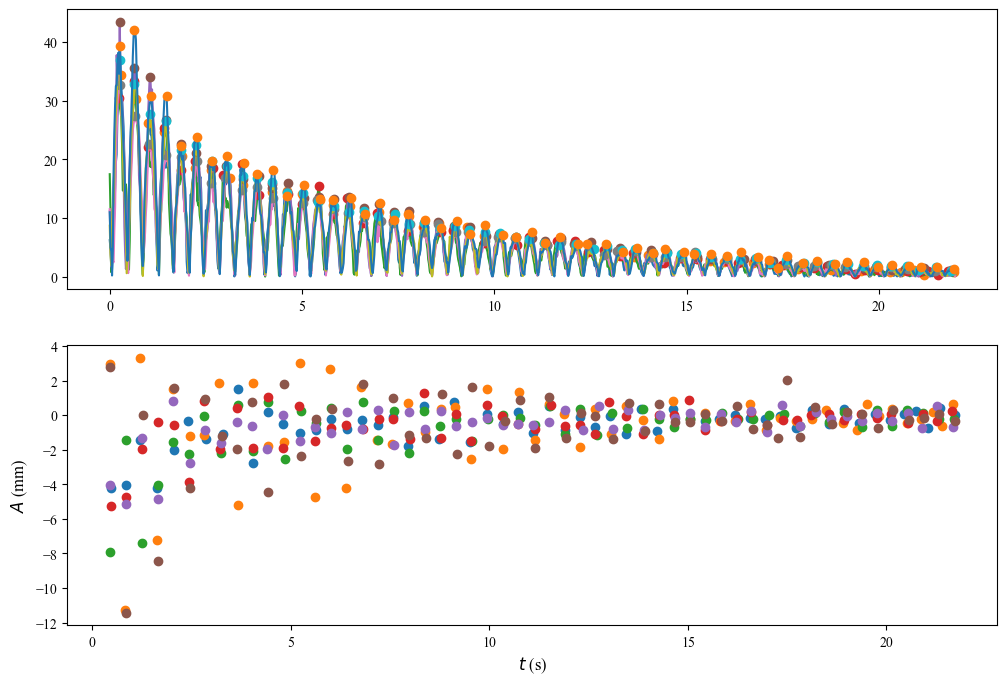

In [60]:
fig,axs = plt.subplots(figsize=(12,8),nrows=2)

colors = {30:'k',40:'r',50:'b'}
for key in data.keys():
    Q = int(key.split('_')[0])
    d = data[key]

    if Q>30:
        y = np.abs(d['A'])
        t = d['t']
        indices = t<22
        y = y[indices]
        t = t[indices]
        values = sig.find_peaks(y,distance = 12)[0]
        #print(values)
        #ax.plot(t,d['A'][indices],colors[Q])
        tm = t[values]
        tc = (tm[1:]+tm[:-1])/2
        yd = np.diff(y[values])
        ax = axs[0]
        ax.plot(t,y)
        ax.plot(t[values],y[values],'o')

        ax = axs[1]
        ax.plot(tc,yd,'o')

        x = t[values]
        yf = y[values]
        p = np.polyfit(x,np.log(yf),1)
        print(Q,-1/p[0])

        xth = np.linspace(0,25,1000)
        yth = np.exp(np.polyval(p,xth))
        #ax.plot(xth,yth,'r--')
        #ax.plot(xth,-yth,'r--')

#ax.set_yscale('log')
#ax.axis([0,10,5,60])
figs = graphes.legende('$t$ (s)','$A$ (mm)','')
#graphes.save_figs(figs,savedir=savefolder)